# Model Training

This notebook trains and runs inference with the two YOLO segmentation models, one per stage. Stage 1 finds melanoma versus everything else, stage 2 segments the remaining diagnosis classes.

Training already ran for both stages, so the train calls here are kept commented out for reference. What we actually run is loading the saved checkpoints and generating predictions on the test set, with and without background removal.


In [14]:
import sys
import warnings
warnings.filterwarnings('ignore')
# add the project root to the path so the src package can be imported
sys.path.append('..')

import os
import yaml
from ultralytics import YOLO
from src.inference_utils.model_predict import predict

from torch import load,device
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from src.classifier.transforms import get_transforms,denorm
from src.classifier.model_builder import build_model,show_model_layers
from src.classifier.class_balance import ClassDistributionPlanner
from src.classifier.losses import FocalLoss
from src.classifier.train import train
from src.utils.visualization import show_curves,show_confusion_matrix
from src.classifier.predict import predict_classifier

from torchvision.utils import make_grid
from torchvision.models import swin_v2_s, Swin_V2_S_Weights

import matplotlib.pyplot as plt
import yaml

## Load configs

We'll pull in the stage 1 config, plus the YOLO data yaml it references. The next few cells just print each one out for a quick look.

In [15]:
s1_data_yaml_path = '../data/processed/Stage-1/data.yaml'
s1_model_args_path = '../data/processed/Stage-1/model_args.yaml'

s2_data_yaml_path = '../data/processed/Stage-2/data.yaml'
s2_model_args_path = '../data/processed/Stage-2/model_args.yaml'

s1_weights = {'best': '../outputs/checkpoints/stage-1/best.pt',
              'last': '../outputs/checkpoints/stage-1/last.pt'}
s2_weights = {'best': '../outputs/checkpoints/stage-2/best.pt',
              'last': '../outputs/checkpoints/stage-2/last.pt'}

s1_save_dir = '../outputs'
s2_save_dir = '../outputs'


with open(s1_data_yaml_path,'r') as f:

    s1_data_yaml = yaml.safe_load(f)

with open(s1_model_args_path,'r') as f:

    s1_model_args = yaml.safe_load(f)


with open(s2_data_yaml_path,'r') as f:

    s2_data_yaml = yaml.safe_load(f)

with open(s2_model_args_path,'r') as f:

    s2_model_args = yaml.safe_load(f)


Let's look at each config to confirm it loaded correctly, starting with the stage 1 data yaml.

In [3]:
s1_data_yaml

{'train': 'C:/Users/ibrah.HIMA/OneDrive/Desktop/Full AI/Projects/GitHub - Kaggle Projects/skin-lesion-segmentation/data/processed/Stage-1/train/images',
 'val': 'C:/Users/ibrah.HIMA/OneDrive/Desktop/Full AI/Projects/GitHub - Kaggle Projects/skin-lesion-segmentation/data/processed/Stage-1/val/images',
 'test': 'C:/Users/ibrah.HIMA/OneDrive/Desktop/Full AI/Projects/GitHub - Kaggle Projects/skin-lesion-segmentation/data/processed/Stage-1/test/images',
 'nc': 2,
 'names': ['Not Mel', 'Mel']}

Now stage 2's data yaml.

In [4]:
s2_data_yaml

{'train': 'C:/Users/ibrah.HIMA/OneDrive/Desktop/Full AI/Projects/GitHub - Kaggle Projects/skin-lesion-segmentation/data/processed/Stage-2/train',
 'val': 'C:/Users/ibrah.HIMA/OneDrive/Desktop/Full AI/Projects/GitHub - Kaggle Projects/skin-lesion-segmentation/data/processed/Stage-2/val',
 'test': 'C:/Users/ibrah.HIMA/OneDrive/Desktop/Full AI/Projects/GitHub - Kaggle Projects/skin-lesion-segmentation/data/processed/Stage-2/test',
 'nc': 6,
 'names': ['AKIEC', 'BCC', 'BKL', 'DF', 'NV', 'VASC']}

And the training arguments for each stage.

In [5]:
s1_model_args

{'epochs': 35,
 'save': True,
 'imgsz': 516,
 'batch': 16,
 'patience': 5,
 'optimizer': 'AdamW',
 'lr0': 0.0005,
 'lrf': 0.01,
 'plots': True,
 'verbose': True,
 'device': 'cuda',
 'workers': 4,
 'project': 'logs',
 'name': 'stage-1',
 'save_dir': '../outputs/logs/stage-1',
 'auto_augment': 'None',
 'augment': True,
 'mosaic': 0.0,
 'mixup': 0.0,
 'copy_paste': 0.0,
 'cutmix': 0.0,
 'hsv_h': 0.015,
 'hsv_s': 0.0,
 'hsv_v': 0.0,
 'scale': 0.05,
 'shear': 0.0,
 'perspective': 0.0,
 'flipud': 0.0,
 'fliplr': 0.0,
 'degrees': 10.0,
 'translate': 0.05,
 'erasing': 0.0}

In [6]:
s2_model_args

{'image_size': 256,
 'epochs': 50,
 'batch_size': 32,
 'patience': 7,
 'lr': 0.0005,
 'weight_decay': 0.0005,
 'drop_out': 0.3,
 'num_workers': 4,
 'device_name': 'cuda'}

## Load the mel semantic model

We start from the base YOLO checkpoint, then load the weights from the last training run. Training already happened, so the training call below stays commented out for reference.

In [ ]:
# load the base checkpoint specified in the config, this is the starting point before training
yolo_model = YOLO('yolo26m-sem.pt')

In [ ]:
# training already ran once; left here commented out for reference
yolo_model.train(data=s1_data_yaml_path, 
                 **s1_model_args, mask_ratio=2)

In [ ]:
# load the checkpoint saved at the end of training, this is the model we'll actually use for inference
mel_seg_model = YOLO(s1_weights['best'])

With the trained stage 1 model loaded, let's run predictions on the test set, first without touching the background.

In [ ]:
predict(mel_seg_model,s1_data_yaml['test'],save_dir=None,remove_background=False)

And again with the background removed, so only the segmented lesion remains in the output image.

In [ ]:
predict(mel_seg_model,s1_data_yaml['test'],save_dir=os.path.join(s1_save_dir, 'predictions/stage-1/'),remove_background=True)

In [7]:
train_dataset = ImageFolder(s2_data_yaml['train'], transform = get_transforms(s2_model_args['image_size'], True))
valid_dataset = ImageFolder(s2_data_yaml['val']  , transform = get_transforms(s2_model_args['image_size']))
test_dataset  = ImageFolder(s2_data_yaml['test'] , transform = get_transforms(s2_model_args['image_size']))

train_dl = DataLoader(train_dataset, batch_size=s2_model_args['batch_size'], shuffle=True , num_workers=s2_model_args['num_workers'], pin_memory=True)
valid_dl = DataLoader(valid_dataset, batch_size=s2_model_args['batch_size'], shuffle=False, num_workers=s2_model_args['num_workers'], pin_memory=True)
test_dl  = DataLoader(test_dataset , batch_size=s2_model_args['batch_size'], shuffle=False, num_workers=s2_model_args['num_workers'], pin_memory=True)
print(train_dataset.classes)

['01_AKIEC', '02_BCC', '03_BKL', '04_DF', '05_NV', '06_VASC']


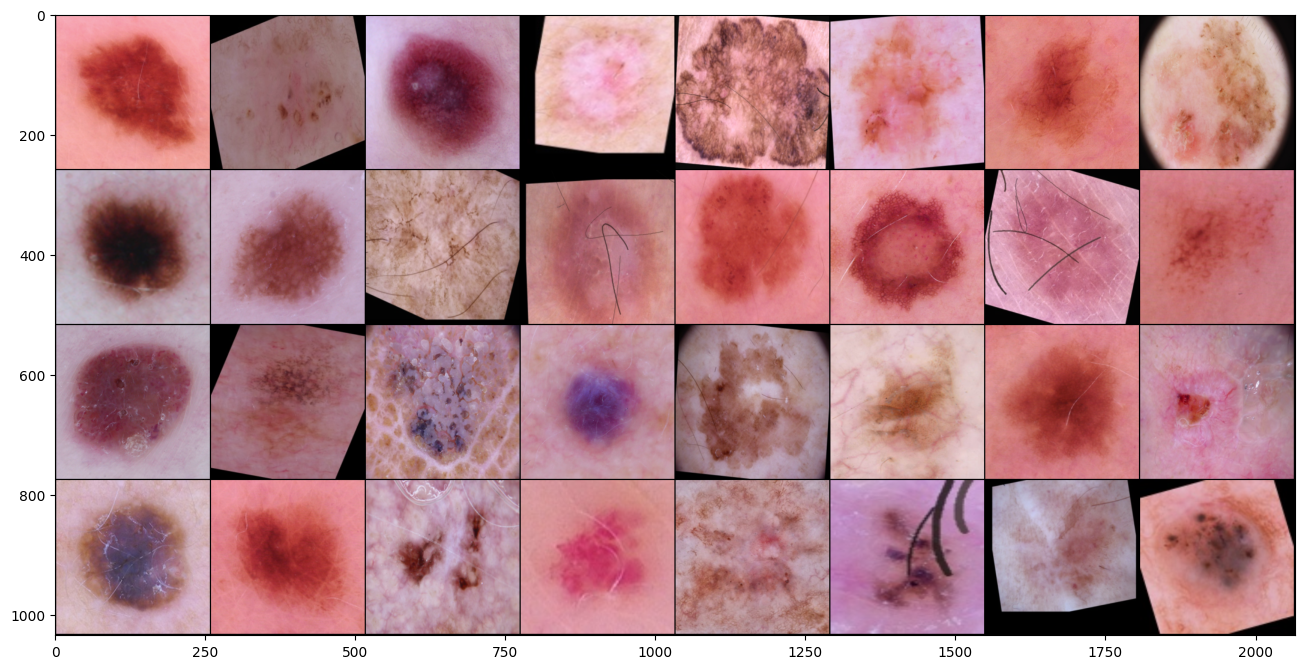

In [8]:
plt.figure(figsize=(16,10))
plt.imshow(make_grid(denorm(next(iter(train_dl))[0])).permute(1,2,0))

In [8]:
model = swin_v2_s(Swin_V2_S_Weights.DEFAULT)
recommended = show_model_layers(model, max_depth=2)
print(recommended)

Layer names for SwinTransformer:
(* = recommended to unfreeze)

Layer                    Trainable / Total Params      Status
--------------------------------------------------------------------------------
features                                               (expanded below)
features.0               4,896 / 4,896                 usually kept frozen
features.1               229,830 / 229,830             usually kept frozen
features.2               74,112 / 74,112               usually kept frozen
features.3               898,956 / 898,956             usually kept frozen
features.4               295,680 / 295,680             usually kept frozen
features.5               32,078,808 / 32,078,808       usually kept frozen
features.6               1,181,184 / 1,181,184         usually kept frozen
features.7               14,203,440 / 14,203,440       * recommended (late backbone block)
norm                     1,536 / 1,536                 * recommended (late backbone block)
permute       

In [9]:
classifier, optimizer, scheduler = build_model(model,
                                               num_classes=s2_data_yaml['nc'],
                                               lr=s2_model_args['lr'],
                                               weight_decay=s2_model_args['weight_decay'],
                                               epochs=s2_model_args['epochs'],
                                               unfreeze_layers=['features.7', 'norm', 'head'],
                                               optimizer_type='sgd',
                                               scheduler_type='cosine',
                                               dropout=s2_model_args['drop_out'],
                                               )

Model Loaded: SwinTransformer (num_classes=6)
Head Replaced: 'head' -> Linear(in_features=768, out_features=6)
Backbone Frozen: True | Head Trainable: True
Selective Unfreeze Enabled: ['features.7', 'norm', 'head']
Trainable Parameters: 14,242,230 / 48,973,056 (29.08%)
Optimizer Loaded: SGD (lr=0.0005, momentum=0.9, weight_decay=0.0005)
Scheduler Loaded: CosineAnnealingLR (T_max=50, eta_min=1e-5)
Model Build Complete


In [10]:
planner = ClassDistributionPlanner({'01_AKIEC': 1320, '02_BCC': 1233, '03_BKL': 1740, '04_DF': 1170, '05_NV': 2399, '06_VASC': 1150}) # These class counts took from projected counts in preprocessing notebook
print(planner.loss_weights())
planner.summary()

tensor([1.0231, 1.0582, 0.9095, 1.0872, 0.8248, 1.0972])
Imbalance ratio (largest/smallest class): 2.1x
  01_AKIEC:   1320
    02_BCC:   1233
    03_BKL:   1740
     04_DF:   1170
     05_NV:   2399
   06_VASC:   1150


'Summary Showed Successfuly'

In [ ]:
classifier, history, best_epoch = train(classifier,
                                        train_dl=train_dl, valid_dl=valid_dl,
                                        epochs=s2_model_args['epochs'],
                                        criterion=FocalLoss(planner.loss_weights()),
                                        optimizer=optimizer,
                                        scheduler=scheduler,
                                        patience=s2_model_args["patience"],
                                        device_name=s2_model_args['device_name'],)

Epoch: 1: 100%|██████████| 282/282 [01:51<00:00,  2.53it/s]


Train Loss: 0.7307, Valid Loss: 0.3162 | Train Accuracy: 0.5286, Valid Accuracy: 0.7482
Epoch 1: LR = 0.0005
  New best saved - loss: 0.3162


Epoch: 2: 100%|██████████| 282/282 [01:49<00:00,  2.58it/s]


Train Loss: 0.4082, Valid Loss: 0.2484 | Train Accuracy: 0.6917, Valid Accuracy: 0.7904
Epoch 2: LR = 0.0004995165484649266
  New best saved - loss: 0.2484


Epoch: 3: 100%|██████████| 282/282 [01:50<00:00,  2.55it/s]


...

Train Loss: 0.1099, Valid Loss: 0.1914 | Train Accuracy: 0.8975, Valid Accuracy: 0.8658
Epoch 29: LR = 0.00020909157792649738
  No improvement (5/7)


Epoch: 30: 100%|██████████| 282/282 [01:50<00:00,  2.55it/s]


Train Loss: 0.1099, Valid Loss: 0.1893 | Train Accuracy: 0.8965, Valid Accuracy: 0.8640
Epoch 30: LR = 0.0001940709776446105
  No improvement (6/7)


Epoch: 31: 100%|██████████| 282/282 [01:49<00:00,  2.57it/s]


Train Loss: 0.1076, Valid Loss: 0.1905 | Train Accuracy: 0.8980, Valid Accuracy: 0.8676
Epoch 31: LR = 0.0001792908363781379
  No improvement (7/7)
Early stopping triggered.
Best Model Loaded Successfully!


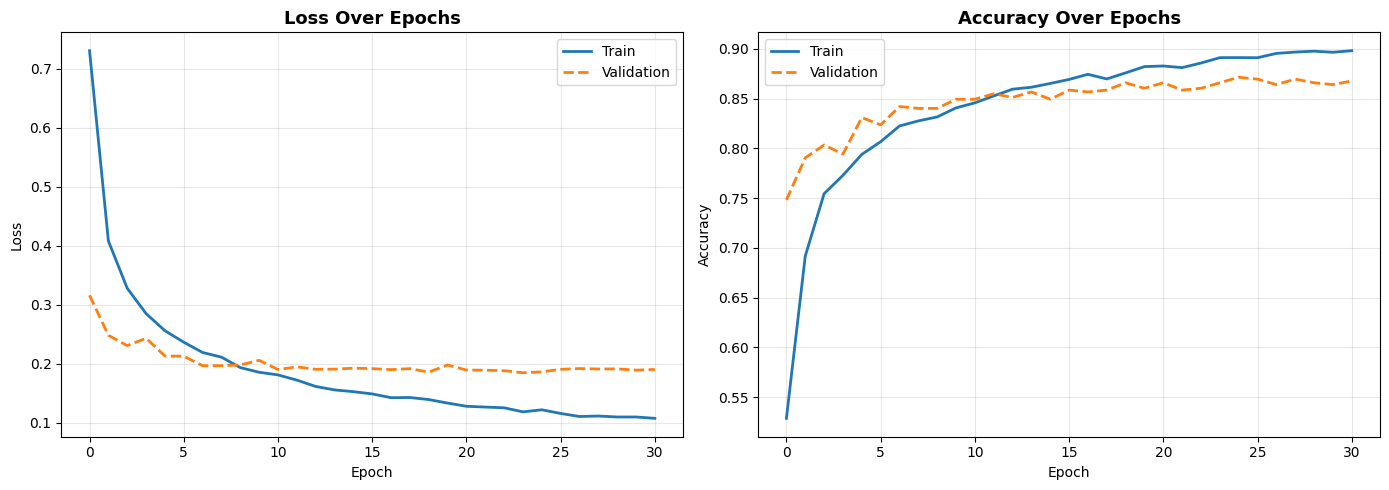

In [19]:
show_curves(history,
            save_dir=os.path.join(s2_save_dir, 'logs/stage-2/')
            )

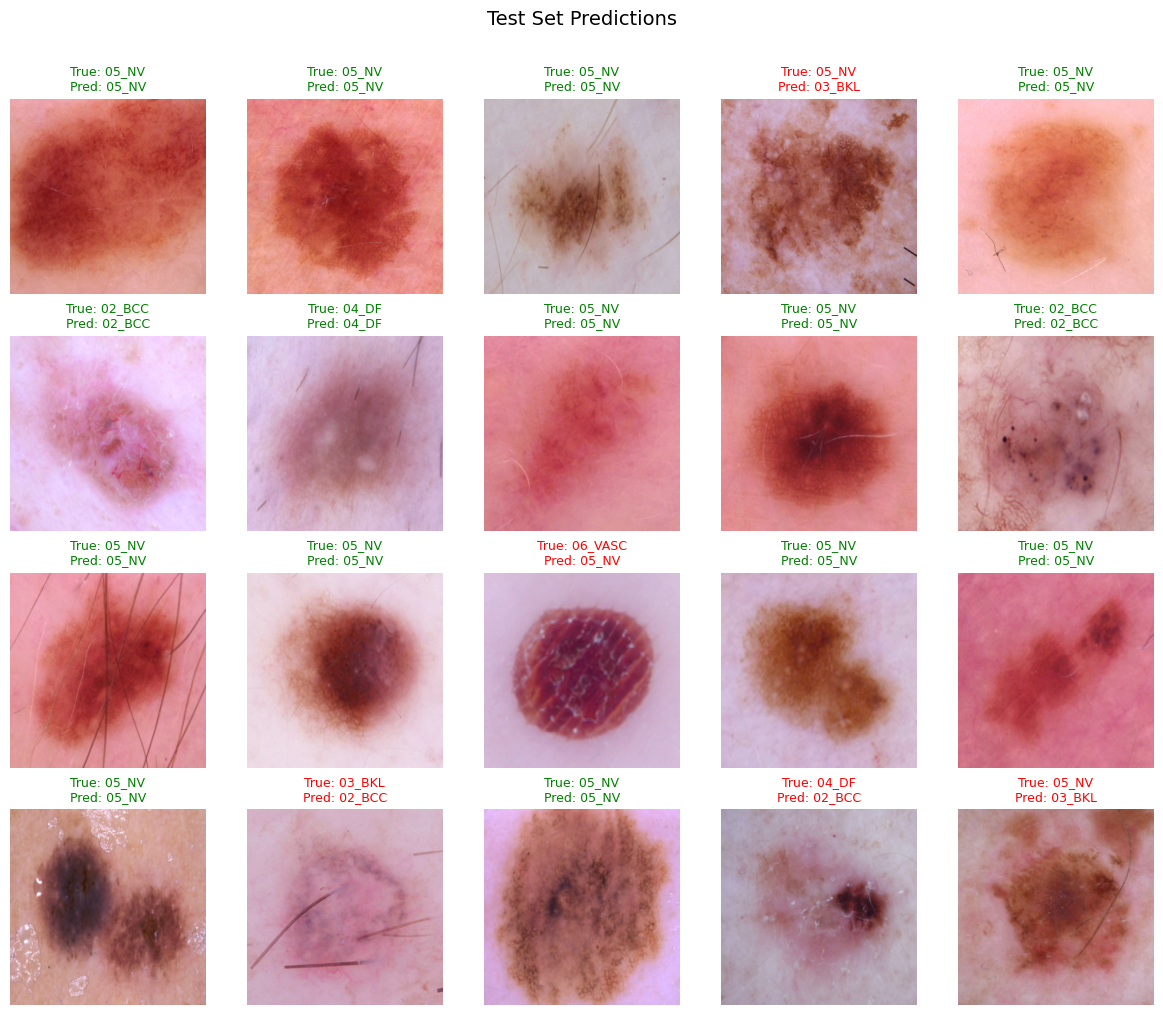

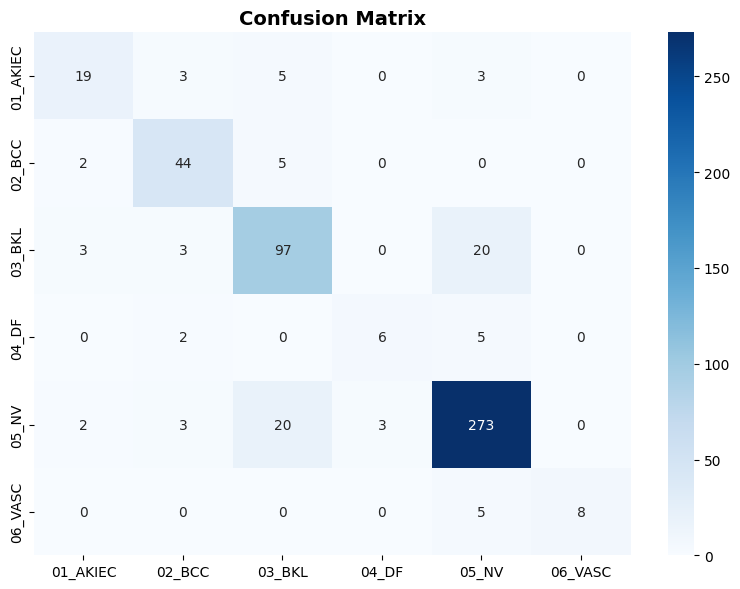

              precision    recall  f1-score   support

    01_AKIEC       0.73      0.63      0.68        30
      02_BCC       0.80      0.86      0.83        51
      03_BKL       0.76      0.79      0.78       123
       04_DF       0.67      0.46      0.55        13
       05_NV       0.89      0.91      0.90       301
     06_VASC       1.00      0.62      0.76        13

    accuracy                           0.84       531
   macro avg       0.81      0.71      0.75       531
weighted avg       0.84      0.84      0.84       531



In [13]:
classifier.load_state_dict(load(s2_weights['last'], map_location= device(s2_model_args['device_name'])))

all_labels, all_preds = predict_classifier(classifier, test_dl, s2_model_args['device_name'], train_dataset.classes,
                                  show_plot=True,
                                  save_plot_path=os.path.join(s2_save_dir, 'predictions/stage-2/')
                                  )

show_confusion_matrix(all_labels,all_preds,train_dataset.classes,
                      save_dir=os.path.join(s2_save_dir, 'logs/stage-2/')
                      )